# 03 · Features — encoding, scaling, engineering

**Dataset:** `data/titanic_clean.csv`.
**Covers:** feature engineering · encoding · scaling · multicollinearity · leakage.
**Time yourself:** ~35 minutes.

The theme of this notebook is **leakage**. Almost every question has a version that
looks right and leaks. If you take one thing away: *split first, fit on train only.*

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/titanic_clean.csv')
df.columns = df.columns.str.lower()
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

## Part A — Feature engineering

### Q1. Create `family_size` (siblings + parents/children + the passenger themself) and a binary `is_alone`. Then check the survival rate by `family_size` — is the relationship monotonic?

<details><summary>hint</summary>

`sibsp + parch + 1`. The `+1` is the passenger. Then group by it and look at the shape of the rates, not just whether they go up.

</details>

In [235]:
# your code here
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

#df.groupby('family_size')['survived'].agg(n='count', rate='mean').round(3)
df.groupby('family_size')['survived'].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64

### Q2. Bin `family_size` into `alone / small / large` — you just saw why. Then compare the
survival rate across the three bins.

<details><summary>hint</summary>

`pd.cut` with bins `[0, 1, 4, 20]` — remember cut is right-inclusive by default, so `(0, 1]` captures exactly family_size == 1.

</details>

In [236]:
# your code here
df["family_bin"] = pd.cut(df["family_size"], bins=[0, 1, 4, 20], labels=["alone", "small", "large"])

### Q3. Extract the **title** (Mr, Mrs, Miss, Master, …) out of `name`. Then collapse the
rare ones into `'Rare'`, keeping only titles with at least 10 passengers.
How many survived per title?

<details><summary>hint</summary>

Names look like `Braund, Mr. Owen Harris` — the title sits between the comma and the period. `.str.extract(r',\s*([^\.]+)\.')` with a capture group.

</details>

In [237]:
# your code here
df['title'] = df['name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
mask = df.groupby("title")["title"].transform("count") < 10
df.loc[mask, "title"] = "rare"
df["title"].value_counts()

title
Mr        517
Miss      182
Mrs       125
Master     40
rare       27
Name: count, dtype: int64

### Q4. Earlier you noted `fare` is per-ticket, not per-person. Fix it: build `fare_per_person`
by dividing the fare by the number of passengers sharing that `ticket`.
Does it correlate with survival better than raw `fare`?

<details><summary>hint</summary>

`df['ticket'].value_counts()` gives counts per ticket; `.map()` broadcasts them back onto every row.

</details>

In [238]:
# your code here
df["fare_per_person"] = df["fare"] / df.groupby("ticket")["fare"].transform("size")
df.query('ticket == "113803"')

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family_size,is_alone,family_bin,title,fare_per_person
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S,2,0,small,Mrs,26.55
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1,C123,S,2,0,small,Mr,26.55


---

## Part B — Split FIRST

Everything from here on learns from data. So the split comes before all of it.

### Q5. Define `X` and `y`, then split 80/20 stratified with `random_state=42`.

Careful about what goes into `X`: drop the identifier and the free-text columns you've
already squeezed. Justify each drop.

<details><summary>hint</summary>

`stratify=y` keeps the ~38% survival rate identical in both splits. Always pass it for classification.

</details>

In [239]:
# your code here
target = "survived"
drop_cols = ["passengerid", "name", "sibsp", "parch", "family_size"] # do not drop "fare" to test it later on VIF
df_drop = df.drop(columns=drop_cols)

y = df_drop.pop(target)
X = df_drop

In [240]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q6. `age` still has NaNs. Impute it with the (`pclass`, `sex`) group median — but do it
**without leaking**. The group medians must come from the training set only.

<details><summary>hint</summary>

Compute the medians on `X_train`, then apply that same lookup to both frames. The fallback `.fillna(X_train['age'].median())` covers a (pclass, sex) combo that only exists in test.

</details>

In [241]:
# your code here
medians_age = X_train.groupby(["pclass", "sex"])["age"].median()

X_train = pd.merge(X_train, medians_age, how="left", on=["pclass", "sex"], suffixes=("", "_median"))
X_test = pd.merge(X_test, medians_age, how="left", on=["pclass", "sex"], suffixes=("", "_median"))

X_test["age"] = X_test["age"].fillna(X_test["age_median"])
X_train["age"] = X_train["age"].fillna(X_train["age_median"])

X_test = X_test.drop(columns=["age_median"])
X_train = X_train.drop(columns=["age_median"])

In [242]:
X_train.age.isnull().sum(), X_test.age.isnull().sum()

(np.int64(0), np.int64(0))

### Q7. Fill the remaining `embarked` NaNs with the training mode.

<details><summary>hint</summary>

Same rule as the median: the mode is a statistic, so it is learned on train.

</details>

In [243]:
# your code here
X_train["embarked"].value_counts(dropna=False)

embarked
S      525
C      125
Q       60
NaN      2
Name: count, dtype: int64

In [244]:
X_train["embarked"] = X_train["embarked"].fillna(X_train["embarked"].mode()[0])
X_test["embarked"] = X_test["embarked"].fillna(X_test["embarked"].mode()[0])

---

## Part C — Encoding

### Q8. Encode the nominal columns (`sex`, `embarked`, `title`, `family_bin`) with one-hot.
Use `drop_first=True` and explain what it prevents.
Then align the train and test columns — and explain why that step is necessary.

<details><summary>hint</summary>

`pd.get_dummies(df, columns=[...], drop_first=True)`. Then `X_test.reindex(columns=X_train.columns, fill_value=0)`. In a real pipeline you'd use `OneHotEncoder(handle_unknown='ignore')` and get this for free.

</details>

In [245]:
# your code here
# pd.get_dummies --> one-hot encoding
nominal = ['sex', 'embarked', 'title', 'family_bin']
X_train_enc = pd.get_dummies(X_train, columns=nominal, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=nominal, drop_first=True)

# drop_first removes one level per column. Without it the dummies of a column sum to 1
# for every row -- perfectly collinear with the intercept ("dummy variable trap"), which
# makes a linear model's coefficients unidentifiable. Trees don't care either way.

# Aligning matters because get_dummies builds columns from the values *present in that
# frame*. If a rare title appears only in train, test ends up a column short and .predict
# throws. Reindex test onto train's columns:
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0) # only done on the test set, not train, because train is the reference.

print(X_train_enc.shape, X_test_enc.shape)
print(list(X_train_enc.columns))

(712, 16) (179, 16)
['pclass', 'age', 'ticket', 'fare', 'cabin', 'is_alone', 'fare_per_person', 'sex_male', 'embarked_Q', 'embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_rare', 'family_bin_small', 'family_bin_large']


In [246]:
X_train_enc

,pclass,age,ticket,fare,cabin,is_alone,fare_per_person,sex_male,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_rare,family_bin_small,family_bin_large
0,1,45.5,113043,28.5000,C124,1,28.500000,True,False,True,False,True,False,False,False,False
1,2,23.0,28425,13.0000,NaN,1,13.000000,True,False,True,False,True,False,False,False,False
2,3,32.0,STON/O 2. 3101293,7.9250,NaN,1,7.925000,True,False,True,False,True,False,False,False,False
3,3,26.0,350025,7.8542,NaN,0,7.854200,True,False,True,False,True,False,False,True,False
4,3,6.0,347082,31.2750,NaN,0,4.467857,False,False,True,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,3,21.0,343120,7.6500,NaN,1,7.650000,False,False,True,True,False,False,False,False,False
708,1,41.0,113798,31.0000,NaN,1,15.500000,True,False,True,False,True,False,False,False,False
709,3,41.0,350026,14.1083,NaN,0,14.108300,True,False,True,False,True,False,False,True,False
710,1,14.0,113760,120.0000,B96 B98,0,30.000000,False,False,True,True,False,False,False,True,False


### Q9. Suppose `deck` had 8 levels and `ticket` had 680. Explain, in a comment, why you would **not** one-hot encode `ticket`, and name two alternatives.

<details><summary>hint</summary>

Think about what 680 columns does to a 891-row dataset.

</details>

In [247]:
# your code here

# if deck has 8 unique values, we could use one-hot (on the limit) or frequency encoding.
# for ticket, if it has 680 unique values, we could use frequency encoding or target encoding.

#   1. Target encoding -- replace each level with the mean target for that level (fit on
#      train only, with smoothing/CV folds, or it leaks the target straight into X).
#   2. Frequency encoding -- replace each level with its count; or extract the structure
#      instead (the ticket prefix, or the group size, as done for fare_per_person).

### Q10. `pclass` is 1/2/3. Should you one-hot it or leave it as an integer? Argue both sides,
then pick one.

<details><summary>hint</summary>

Is it ordered? Yes. Are the gaps between levels equal? Look at the rates.

</details>

<Axes: title={'center': 'Survival Rate by Pclass'}, xlabel='pclass'>

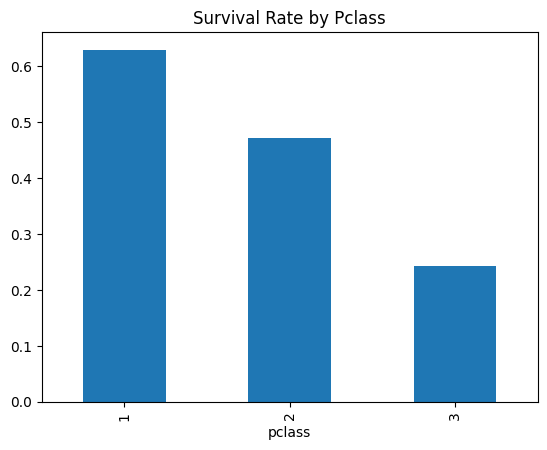

In [248]:
# your code here
df.groupby("pclass")["survived"].mean().plot(kind="bar", title="Survival Rate by Pclass")

# leave it as it is ordered and monotonic

---

## Part D — Scaling & multicollinearity

### Q11. Scale the features with `StandardScaler` for a logistic regression. Fit on train,
transform both. Then show — with a number — that you did not leak.

<details><summary>hint</summary>

`fit_transform` on train, `transform` on test. Then check: is the test mean exactly 0? It shouldn't be.

</details>

In [249]:
# your code here
from sklearn.preprocessing import StandardScaler

scal_cols = ["age", "fare_per_person"]
ss = StandardScaler()
X_train_enc[scal_cols] = ss.fit_transform(X_train_enc[scal_cols]) 
X_test_enc[scal_cols] = ss.transform(X_test_enc[scal_cols]) 

In [250]:
X_train_enc.head()

,pclass,age,ticket,fare,cabin,is_alone,fare_per_person,sex_male,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_rare,family_bin_small,family_bin_large
0,1,1.239505,113043,28.5000,C124,1,0.552664,True,False,True,False,True,False,False,False,False
1,2,-0.458148,28425,13.0000,NaN,1,-0.212086,True,False,True,False,True,False,False,False,False
2,3,0.220913,STON/O 2. 3101293,7.9250,NaN,1,-0.462480,True,False,True,False,True,False,False,False,False
3,3,-0.231794,350025,7.8542,NaN,0,-0.465973,True,False,True,False,True,False,False,True,False
4,3,-1.740819,347082,31.2750,NaN,0,-0.633051,False,False,True,True,False,False,False,False,True


### Q12. Would you scale for a `RandomForestClassifier`? Explain in one sentence, and say whether scaling would *hurt* if you did it anyway.

<details><summary>hint</summary>

What does a tree actually do with a feature's value?

</details>

In [251]:
# your code here
# No. A tree splits on thresholds ("age < 12"), and any monotonic rescaling maps that
# threshold to an equivalent one -- the tree structure is unchanged. It wouldn't hurt
# accuracy, it's just wasted compute and one more fitted object to keep in sync at
# serving time. Scaling matters for models that use distances or coefficient magnitudes:
# KNN, SVM, linear/logistic regression, PCA, neural nets.

### Q13. Compute the VIF for the numeric features. Is anything above the usual threshold of 10?
Whatever the answer, find the redundant pair — VIF is not the only tool you have.

<details><summary>hint</summary>

`variance_inflation_factor(X.values, i)` for each column index. Cast to float — it chokes on bool dummies. Then check `.corr()` on the pair you suspect and see whether the two tools agree.

</details>

In [ ]:
# your code here

from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = ['pclass', 'age', 'fare_per_person', "fare", 'is_alone']
Xv = X_train_enc[num_cols].astype(float)

vif = pd.DataFrame({
    'feature': num_cols,
    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
}).sort_values('VIF', ascending=False)
display(vif.round(2))

# VIF here is computed WITHOUT an intercept (statsmodels doesn't add one), which
# distorts the absolute values. This means that the VIFs are not directly comparable to the textbook threshold of 5 or 10, 
# but the relative values are still meaningful.

print('\ncorr(fare, fare_per_person) =',
      round(X_train_enc[['fare', 'fare_per_person']].corr().iloc[0, 1], 3))
# we should drop one of the two features, because they are highly correlated. The VIFs are also high, indicating multicollinearity.

,feature,VIF
3,fare,4.94
2,fare_per_person,4.69
0,pclass,4.42
4,is_alone,2.71
1,age,1.21



corr(fare, fare_per_person) = 0.854


In [ ]:
num_cols = ['pclass', 'age', 'fare_per_person', 'is_alone']
Xv = X_train_enc[num_cols].astype(float)

vif = pd.DataFrame({
    'feature': num_cols,
    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
}).sort_values('VIF', ascending=False)
display(vif.round(2))

# now all are below 3, which is acceptable. We dropped "fare" to reduce multicollinearity, as it was highly correlated with "fare_per_person".

,feature,VIF
0,pclass,2.75
3,is_alone,2.69
1,age,1.21
2,fare_per_person,1.10


### Q14. Resolve the collinearity you found. Then state which models actually needed you to bother.

<details><summary>hint</summary>

Drop one of each redundant pair, keeping the more interpretable one.

</details>

In [ ]:
# your code here

X_train_enc = X_train_enc.drop(columns=["fare"])
X_test_enc = X_test_enc.drop(columns=["fare"])

# Who needed this: plain logistic/linear regression, where collinearity makes coefficients
# unstable and their signs unreadable -- fatal if the coefficient is the deliverable.
# Who didn't: Random Forest, XGBoost (they just split on whichever correlate they see
# first -- it dilutes feature importances but not accuracy), and Ridge/Lasso, which are
# built to absorb exactly this.

---

## Part E — Do it properly

### Q15. Everything above was done by hand and is a pain to reproduce at serving time. Rebuild
it as a single `ColumnTransformer` + `Pipeline` that takes raw columns in and gives
predictions out. Cross-validate it.

This is the answer they want when they ask *"how would you productionise this?"*

<details><summary>hint</summary>

`ColumnTransformer([('num', num_pipe, numeric_cols), ('cat', cat_pipe, cat_cols)])`, then wrap it with the classifier in a `Pipeline`. Use `OneHotEncoder(handle_unknown='ignore')` so an unseen category at predict time doesn't crash you.

</details>

In [ ]:
# your code here

---

## Debrief

The five leakage traps in this notebook, in the order people fall into them:

1. **Imputing before splitting** — the median you fill test with was computed using test.
2. **`fit_transform` on the test set** — the scaler learns the test distribution.
3. **Target encoding without CV folds** — puts the answer directly into a feature.
4. **Feature selection on the full dataset** — you chose the features using test.
5. **Tuning against the test set** — after the first peek, it isn't a test set any more.

If you build a `Pipeline`, 1–4 stop being possible. Only #5 stays your problem.